In [1]:
import duckdb as duckdb
from dotenv import load_dotenv
import os

load_dotenv()

True

In [2]:
db_path = os.getenv("DB_PATH")
data_path = os.getenv("DATA_PATH")

In [5]:
con = duckdb.connect(database= db_path)

In [18]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_timeseries(con, data_path, id, from_date, to_date):
    """Plot the timeseries for a given id between from_date and to_date.

    Args:
        con: DuckDB connection.
        data_path: Path to the parquet data.
        id: The series id to plot.
        from_date: Start date (inclusive), e.g. '2024-01-01'.
        to_date: End date (inclusive), e.g. '2024-01-31'.
    """
    query = f"""
    select id, dia, hora, valor
    from read_parquet('{data_path}')
    where id = {id}
      and dia >= '{from_date}'
      and dia <= '{to_date}'
    order by dia, hora
    """
    df = con.query(query).to_df()

    df["timestamp"] = pd.to_datetime(df["dia"].astype(str)) + pd.to_timedelta(df["hora"] - 1, unit="h")

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(df["timestamp"], df["valor"], linewidth=1)
    #ax.set_title(f"ID {id}  —  {from_date} to {to_date}")
    #ax.set_xlabel("Timestamp")
    #ax.set_ylabel("Valor")
    fig.tight_layout()
    plt.show()

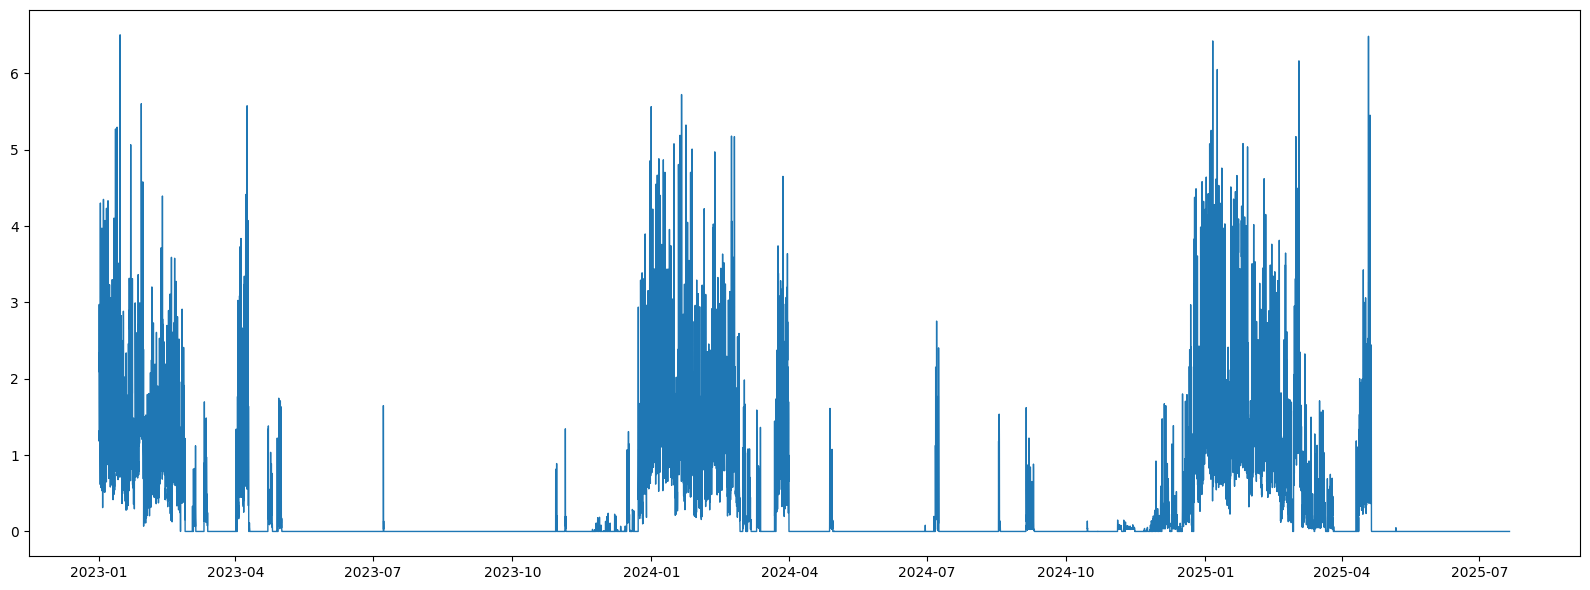

In [ ]:
#16807863

plot_timeseries(con, data_path, id=16807863, from_date="2023-01-01", to_date="2025-07-20")